In [ ]:
#Installing Libraries
!pip install open_clip_torch
!pip install ftfy regex tqdm

In [2]:
# Importing Libraries
import torch
import open_clip
import torchvision
import numpy as np
import matplotlib.pyplot as plt
from torchvision import datasets
from torchvision import transforms
from torch.utils.data import DataLoader
from tqdm import tqdm

In [3]:
# Setting Device
device = "cuda" if torch.cuda.is_available() else "cpu"

In [4]:
# Loading CLIP Model
model, _, preprocess = open_clip.create_model_and_transforms(
    'ViT-B-16',
    pretrained='openai'
)

tokenizer = open_clip.get_tokenizer('ViT-B-16')
model = model.to(device)
model.eval()
print("CLIP Loaded Successfully!")

/usr/local/lib/python3.12/dist-packages/huggingface_hub/utils/_auth.py:112: UserWarning: 
The secret `HF_TOKEN` does not exist in your Colab secrets.
To authenticate with the Hugging Face Hub, create a token in your settings tab (https://huggingface.co/settings/tokens), set it as secret in your Google Colab and restart your session.
You will be able to reuse this secret in all of your notebooks.
Please note that authentication is recommended but still optional to access public models or datasets.
  warnings.warn(


open_clip_model.safetensors:   0%|          | 0.00/599M [00:00<?, ?B/s]

/usr/local/lib/python3.12/dist-packages/open_clip/factory.py:450: UserWarning: QuickGELU mismatch between final model config (quick_gelu=False) and pretrained tag 'openai' (quick_gelu=True).
  warnings.warn(


CLIP Loaded Successfully!


In [5]:
# Transforming and Loading CIFAR-100 Dataset
transform = transforms.Compose([
    transforms.Resize((224, 224)),
    transforms.ToTensor(),
    transforms.Normalize(
        mean=[0.48145466, 0.4578275, 0.40821073],
        std=[0.26862954, 0.26130258, 0.27577711]
    )
])

test_dataset = datasets.CIFAR100(
    root='./data',
    train=False,
    download=True,
    transform=transform
)

class_names = test_dataset.classes
test_loader = DataLoader(
    test_dataset,
    batch_size=64,
    shuffle=False
)

print("Test Dataset Loaded!")
print("Number of Classes:", len(class_names))

100%|██████████| 169M/169M [00:04<00:00, 33.8MB/s]


Test Dataset Loaded!
Number of Classes: 100


In [7]:
# Creation of standard Prompts
standard_prompts = [
    f"a photo of a {class_name}"
    for class_name in class_names
]


In [9]:
# Encoding Text Prompts
text_tokens = tokenizer(standard_prompts).to(device)

with torch.no_grad():

    text_features = model.encode_text(text_tokens)
    text_features /= text_features.norm(dim=-1, keepdim=True)

print(text_features.shape)

torch.Size([100, 512])


In [14]:
# Full Dataset Evaluation
correct = 0
total = 0

all_predictions = []
all_labels = []

with torch.no_grad():

    for images, labels in tqdm(test_loader):

        images = images.to(device)
        image_features = model.encode_image(images)
        image_features /= image_features.norm(
            dim=-1,
            keepdim=True
        )

        similarity = (
            100.0 * image_features @ text_features.T
        )

        predictions = similarity.argmax(dim=-1)
        correct += (
            predictions.cpu() == labels
        ).sum().item()

        total += labels.size(0)
        all_predictions.extend(predictions.cpu().numpy())
        all_labels.extend(labels.numpy())

final_accuracy = correct / total

print("\nFINAL CLIP ACCURACY")
print(f"{final_accuracy * 100:.2f}%")

100%|██████████| 157/157 [02:23<00:00,  1.09it/s]


FINAL CLIP ACCURACY
59.33%


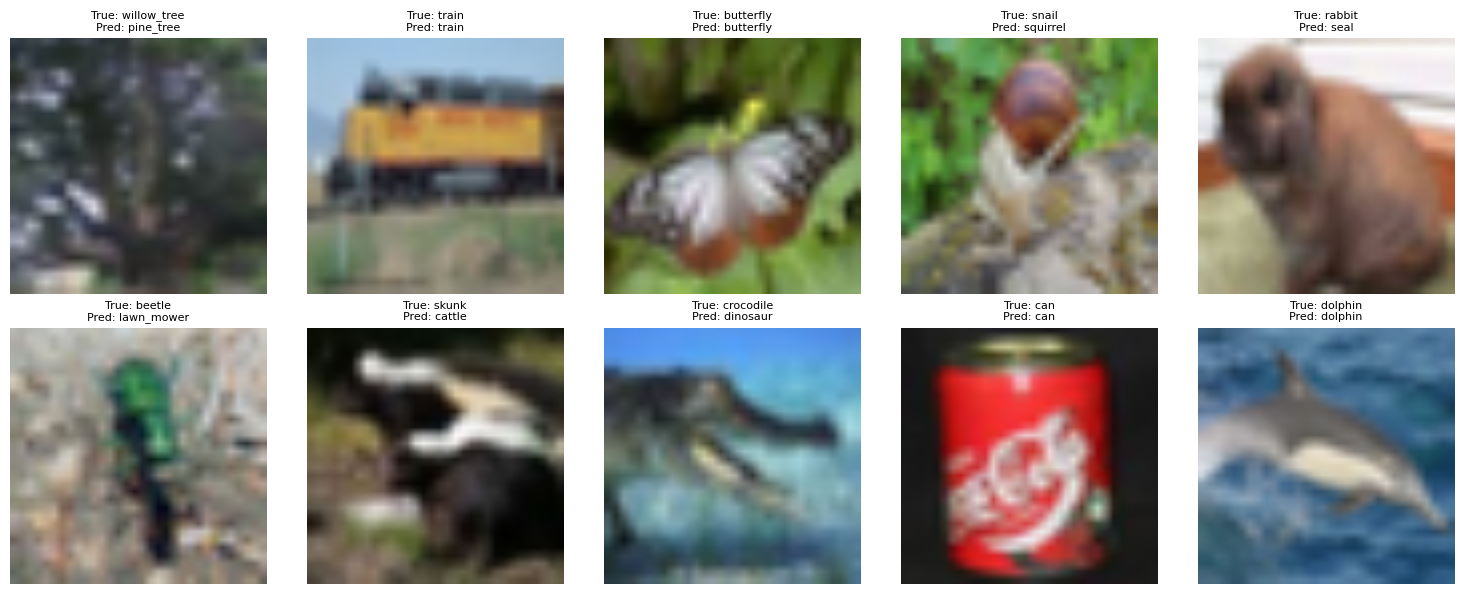

In [15]:
# Visualizing Prediction
def unnormalize(img):

    mean = torch.tensor(
        [0.48145466, 0.4578275, 0.40821073]
    ).view(3,1,1)

    std = torch.tensor(
        [0.26862954, 0.26130258, 0.27577711]
    ).view(3,1,1)

    img = img * std + mean
    return img


fig, axes = plt.subplots(2, 5, figsize=(15,6))

for i, ax in enumerate(axes.flat):

    image = unnormalize(images[i].cpu())
    image = image.permute(1,2,0).numpy()
    true_label = class_names[labels[i]]
    predicted_label = class_names[
        predictions[i]
    ]

    ax.imshow(image)
    ax.set_title(
        f"True: {true_label}\nPred: {predicted_label}",
        fontsize=8
    )

    ax.axis('off')

plt.tight_layout()
plt.show()

In [16]:
# Baseline Result
baseline_accuracy = final_accuracy * 100
print(f"Standard CLIP Baseline Accuracy: {baseline_accuracy:.2f}%")

Standard CLIP Baseline Accuracy: 59.33%
